In [1]:
# Latex macros -- ignore
from IPython.display import display, Math
with open('macros.tex', 'r') as f:
        macros = f.read()
display(Math(macros))

<IPython.core.display.Math object>

In [2]:
from IPython.display import Latex
def showState(label, state):
    stateSource = state.draw("latex_source")
    display(Latex(label + " $= " + stateSource + "$"))

# IBM Runtime Service

In [ ]:
pip install qiskit-ibm-runtime

## Credentials

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
token="-----------", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="--------", # Optional
overwrite=True
)

## Service

In [8]:
    from qiskit_ibm_runtime import QiskitRuntimeService

    # Run every time you need the service
    service = QiskitRuntimeService()

## Ideal circuit

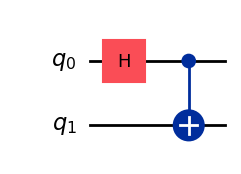

In [9]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorOptions
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from matplotlib import pyplot as plt
# Uncomment the next line if you want to use a simulator:
# from qiskit_ibm_runtime.fake_provider import FakeBelemV2


# Create a new circuit with two qubits
qc = QuantumCircuit(2)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)

# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

### Observables

In [10]:
# Set up six different observables.

observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]
observables = [SparsePauliOp(label) for label in observables_labels]

### Transpilation

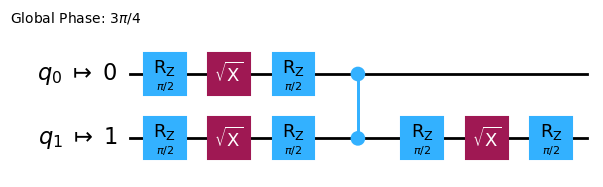

In [11]:
service = QiskitRuntimeService()

backend = service.least_busy(simulator=False, operational=True)

# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

isa_circuit.draw("mpl", idle_wires=False)

### Execution

In [12]:
# Construct the Estimator instance.

estimator = Estimator(mode=backend)
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000

mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]

# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observables)])

# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d711ruif84ks73dguqbg


In [14]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()

# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]

### Analysis

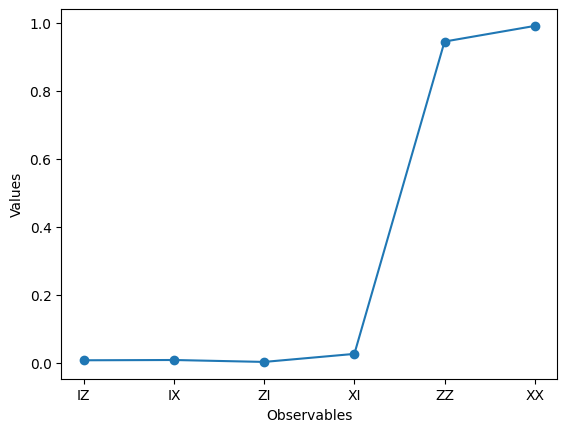

In [15]:
# Plot the result

values = pub_result.data.evs

errors = pub_result.data.stds

# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()

## Configuration

In [16]:
config = backend.configuration()

print(f"Name: {config.backend_name}")
print(f"Qubits: {config.n_qubits}")
print(f"Basis Gates: {config.basis_gates}")
print(f"Coupling Map: {config.coupling_map}")

Name: ibm_fez
Qubits: 156
Basis Gates: ['cz', 'id', 'rz', 'sx', 'x']
Coupling Map: [[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [3, 16], [4, 3], [4, 5], [5, 4], [5, 6], [6, 5], [6, 7], [7, 6], [7, 8], [7, 17], [8, 7], [8, 9], [9, 8], [9, 10], [10, 9], [10, 11], [11, 10], [11, 12], [11, 18], [12, 11], [12, 13], [13, 12], [13, 14], [14, 13], [14, 15], [15, 14], [15, 19], [16, 3], [16, 23], [17, 7], [17, 27], [18, 11], [18, 31], [19, 15], [19, 35], [20, 21], [21, 20], [21, 22], [21, 36], [22, 21], [22, 23], [23, 16], [23, 22], [23, 24], [24, 23], [24, 25], [25, 24], [25, 26], [25, 37], [26, 25], [26, 27], [27, 17], [27, 26], [27, 28], [28, 27], [28, 29], [29, 28], [29, 30], [29, 38], [30, 29], [30, 31], [31, 18], [31, 30], [31, 32], [32, 31], [32, 33], [33, 32], [33, 34], [33, 39], [34, 33], [34, 35], [35, 19], [35, 34], [36, 21], [36, 41], [37, 25], [37, 45], [38, 29], [38, 49], [39, 33], [39, 53], [40, 41], [41, 36], [41, 40], [41, 42], [42, 41], [42, 43], [43, 42], [43, 44]

## Live properties (update every 24 hours)

In [20]:
properties = backend.properties()

# Get T1 time for a specific qubit (e.g., Qubit 0)
t1_0 = properties.t1(0) 

# Get the error rate of a specific gate
cz_error = properties.gate_error('cz', [0, 1])

print(f"Qubit 0 T1: {t1_0 * 1e6:.2f} µs")
print(f"CZ (0,1) Error: {cz_error:.4%}")

Qubit 0 T1: 52.62 µs
CZ (0,1) Error: 0.8777%
